In [2]:
# --- CÉLULA 1: SETUP E CARREGAMENTO ---
import os, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports de ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve

# Configurações
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("--- Iniciando Notebook 02 ---")

# Detectar ambiente: Colab ou Local
NO_COLAB = os.path.exists('/content')

if NO_COLAB:
    # No Colab: clonar repo do GitHub
    repo_dir = '/content/tcc-analise-sentimento'
    if os.path.exists(repo_dir):
        print("Repo já existe, atualizando...")
        subprocess.run(['git', '-C', repo_dir, 'pull'], check=True)
    else:
        print("Clonando repositório...")
        subprocess.run(['git', 'clone',
            'https://github.com/ROMAUSKI/tcc-analise-sentimento.git',
            repo_dir], check=True)
    base_dir = repo_dir
else:
    # Local (VS Code): usar caminho relativo ao notebook
    base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Executando localmente. Base: {base_dir}")

# Carregar dados
caminho_csv = os.path.join(base_dir, 'dados', 'processado', 'synthetic_dataset.csv')

try:
    df = pd.read_csv(caminho_csv)
    df = df.dropna(subset=['frase_limpa'])

    X = df['frase_limpa']
    y = df['classe']

    print(f"\n✅ Sucesso! Dataset carregado com {len(df)} linhas.")
    print("X e y definidos.")

except FileNotFoundError:
    print(f"\n❌ ERRO: Não encontrei o arquivo em: {caminho_csv}")
    print("Verifique a estrutura de pastas do projeto.")
except Exception as e:
    print(f"\n❌ Ocorreu um erro: {e}")

--- Iniciando Notebook 02 ---
Executando localmente. Base: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento

✅ Sucesso! Dataset carregado com 1798 linhas.
X e y definidos.


In [3]:
# --- CÉLULA 2: VALIDAÇÃO CRUZADA (Accuracy + F1-Score) ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Pipeline base: TF-IDF + Classificador
def criar_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', clf)
    ])

# Definir experimentos: (nome, classificador, k)
experimentos = [
    ('Naive Bayes (k=5)',  MultinomialNB(), 5),
    ('Naive Bayes (k=10)', MultinomialNB(), 10),
    ('Regressão Logística (k=5)',  LogisticRegression(max_iter=1000), 5),
    ('Regressão Logística (k=10)', LogisticRegression(max_iter=1000), 10),
]

# Executar e armazenar resultados
resultados = []

print("=" * 65)
print("  VALIDAÇÃO CRUZADA — Accuracy e F1-Score por experimento")
print("=" * 65)

for nome, clf, k in experimentos:
    pipe_acc = criar_pipeline(clf)
    pipe_f1  = criar_pipeline(clf)

    scores_acc = cross_val_score(pipe_acc, X, y, cv=k, scoring='accuracy')
    scores_f1  = cross_val_score(pipe_f1,  X, y, cv=k, scoring='f1_weighted')

    acc_pct = scores_acc * 100
    f1_pct  = scores_f1  * 100

    resultados.append({
        'Modelo': nome,
        'k': k,
        'Acc Média': scores_acc.mean(),
        'Acc DP': scores_acc.std(),
        'F1 Média': scores_f1.mean(),
        'F1 DP': scores_f1.std(),
        'Scores Acc': scores_acc,
        'Scores F1': scores_f1
    })

    folds_acc = ', '.join([f"{s:.2f}%" for s in acc_pct])
    folds_f1  = ', '.join([f"{s:.2f}%" for s in f1_pct])

    print(f"\n📌 {nome}")
    print(f"   Accuracy — Folds: [{folds_acc}]")
    print(f"              Média: {acc_pct.mean():.6f}% ± {acc_pct.std():.6f}%")
    print(f"   F1-Score — Folds: [{folds_f1}]")
    print(f"              Média: {f1_pct.mean():.6f}% ± {f1_pct.std():.6f}%")

    # Legenda curta
    if acc_pct.std() < 1.0:
        print(f"   → Modelo estável (baixa variância).")
    elif acc_pct.std() < 2.0:
        print(f"   → Desempenho consistente (variância moderada).")
    else:
        print(f"   → Desempenho oscila entre folds (alta variância).")

print("\n" + "=" * 65)

# Resumo em DataFrame
df_cv = pd.DataFrame([{
    'Modelo': r['Modelo'],
    'k': r['k'],
    'Accuracy Média (%)': f"{r['Acc Média'] * 100:.6f}",
    'Accuracy DP (%)': f"{r['Acc DP'] * 100:.6f}",
    'F1-Score Média (%)': f"{r['F1 Média'] * 100:.6f}",
    'F1-Score DP (%)': f"{r['F1 DP'] * 100:.6f}"
} for r in resultados])

print("\n📊 Resumo da Validação Cruzada:")
print(df_cv.to_string(index=False))
print("\nLegenda: Accuracy = taxa de acertos; F1 = média ponderada de precisão e recall; DP = desvio padrão entre folds.")

  VALIDAÇÃO CRUZADA — Accuracy e F1-Score por experimento

📌 Naive Bayes (k=5)
   Accuracy — Folds: [89.17%, 88.33%, 88.33%, 89.42%, 90.25%]
              Média: 89.099814% ± 0.721575%
   F1-Score — Folds: [89.16%, 88.33%, 88.35%, 89.42%, 90.29%]
              Média: 89.107628% ± 0.731193%
   → Modelo estável (baixa variância).

📌 Naive Bayes (k=10)
   Accuracy — Folds: [91.11%, 87.78%, 87.22%, 87.22%, 88.89%, 91.11%, 91.11%, 87.78%, 87.15%, 91.62%]
              Média: 89.099317% ± 1.813204%
   F1-Score — Folds: [91.08%, 87.77%, 87.15%, 87.24%, 88.98%, 91.07%, 91.14%, 87.77%, 87.16%, 91.69%]
              Média: 89.105894% ± 1.823337%
   → Desempenho consistente (variância moderada).

📌 Regressão Logística (k=5)
   Accuracy — Folds: [88.06%, 87.78%, 88.89%, 85.24%, 85.24%]
              Média: 87.039152% ± 1.516400%
   F1-Score — Folds: [88.06%, 87.68%, 88.89%, 85.21%, 85.14%]
              Média: 86.995631% ± 1.537905%
   → Desempenho consistente (variância moderada).

📌 Regressão Lo

In [4]:
# --- CÉLULA 3: SALVAR RESULTADOS EM CSV ---
# Diretório de resultados (compatível Colab/Local)
dir_resultados = os.path.join(base_dir, 'resultados')
os.makedirs(dir_resultados, exist_ok=True)

# Salvar tabela comparativa
caminho_csv_resultado = os.path.join(dir_resultados, 'validacao_cruzada.csv')
df_cv.to_csv(caminho_csv_resultado, index=False)

print(f"✅ Tabela salva em: {caminho_csv_resultado}")
print(f"\n{df_cv.to_string(index=False)}")

✅ Tabela salva em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\validacao_cruzada.csv

                    Modelo  k Accuracy Média (%) Accuracy DP (%) F1-Score Média (%) F1-Score DP (%)
         Naive Bayes (k=5)  5          89.099814        0.721575          89.107628        0.731193
        Naive Bayes (k=10) 10          89.099317        1.813204          89.105894        1.823337
 Regressão Logística (k=5)  5          87.039152        1.516400          86.995631        1.537905
Regressão Logística (k=10) 10          87.596214        2.703767          87.532606        2.779426


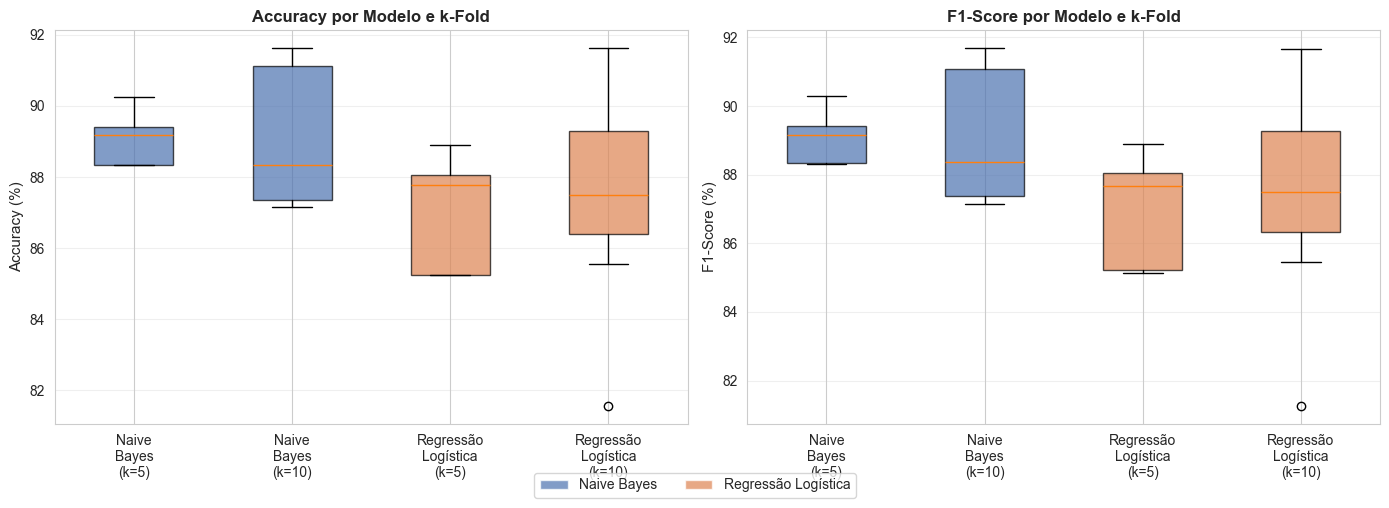


✅ Gráfico salvo em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\boxplot_validacao_cruzada.png


In [5]:
# --- CÉLULA 4: BOXPLOT COMPARATIVO DOS K-FOLDS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Preparar dados para boxplot
dados_acc = {r['Modelo']: r['Scores Acc'] * 100 for r in resultados}
dados_f1  = {r['Modelo']: r['Scores F1']  * 100 for r in resultados}

# --- Boxplot Accuracy ---
ax1 = axes[0]
bp1 = ax1.boxplot(dados_acc.values(), labels=[n.replace(' ', '\n') for n in dados_acc.keys()],
                   patch_artist=True, widths=0.5)
cores = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
for patch, cor in zip(bp1['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax1.set_title('Accuracy por Modelo e k-Fold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# --- Boxplot F1-Score ---
ax2 = axes[1]
bp2 = ax2.boxplot(dados_f1.values(), labels=[n.replace(' ', '\n') for n in dados_f1.keys()],
                   patch_artist=True, widths=0.5)
for patch, cor in zip(bp2['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax2.set_title('F1-Score por Modelo e k-Fold', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score (%)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Legenda manual
from matplotlib.patches import Patch
legenda = [Patch(facecolor='#4C72B0', alpha=0.7, label='Naive Bayes'),
           Patch(facecolor='#DD8452', alpha=0.7, label='Regressão Logística')]
fig.legend(handles=legenda, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()

# Salvar
caminho_boxplot = os.path.join(dir_resultados, 'boxplot_validacao_cruzada.png')
fig.savefig(caminho_boxplot, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico salvo em: {caminho_boxplot}")

  CURVA DE APRENDIZADO — F1-Score (Treino vs Validação CV)

📌 Naive Bayes
   Fração   N amostras   F1 Treino (%)      F1 Validação (%)
   0.1      143          99.8598            67.4218
   0.2      287          99.9303            76.9294
   0.3      431          99.3029            80.6549
   0.4      575          99.4086            83.3583
   0.5      719          98.8880            85.2963
   0.6      862          98.8642            86.7901
   0.7      1006         98.9677            87.3048
   0.8      1150         98.8352            88.3462
   0.9      1294         98.7023            88.7756
   1.0      1438         98.5684            89.1076


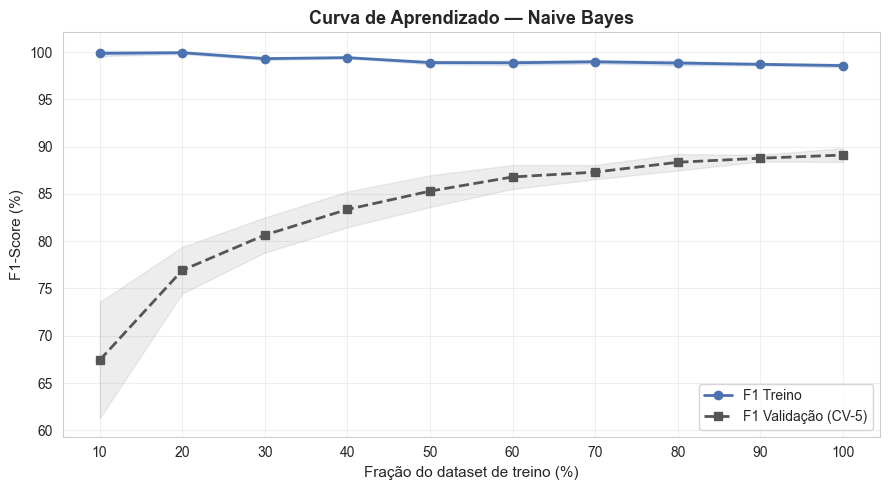

   ✅ Gráfico salvo em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\curva_aprendizado_nb.png

📌 Regressão Logística
   Fração   N amostras   F1 Treino (%)      F1 Validação (%)
   0.1      143          100.0000           65.8257
   0.2      287          99.6515            73.1737
   0.3      431          99.2576            77.2260
   0.4      575          99.2349            81.7738
   0.5      719          98.7213            83.5596
   0.6      862          98.5623            84.0924
   0.7      1006         98.4882            84.7634
   0.8      1150         98.2598            85.5790
   0.9      1294         97.9732            86.3892
   1.0      1438         97.8705            87.0488


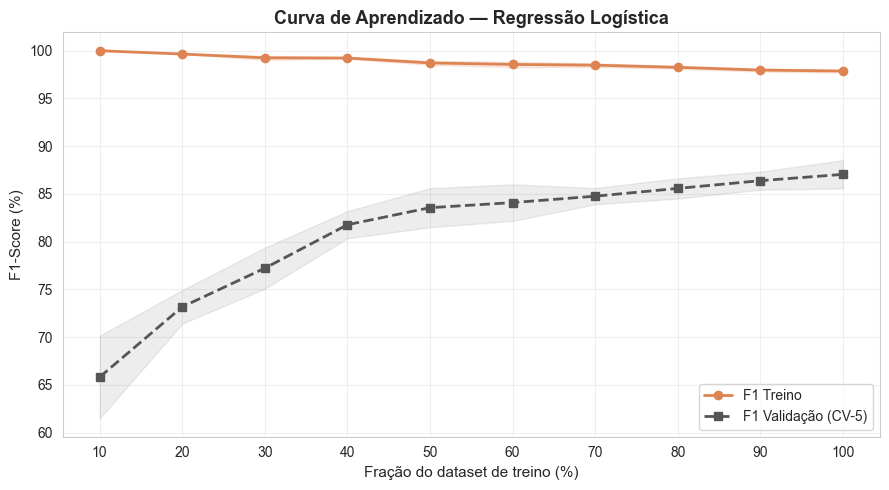

   ✅ Gráfico salvo em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\curva_aprendizado_lr.png



In [6]:
# --- CÉLULA 5: CURVA DE APRENDIZADO (NB e LR) ---
from sklearn.model_selection import learning_curve

# Frações do dataset de treino
train_sizes_frac = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

modelos_lc = [
    ('Naive Bayes',          MultinomialNB(),                      'curva_aprendizado_nb.png', '#4C72B0'),
    ('Regressão Logística',  LogisticRegression(max_iter=1000),    'curva_aprendizado_lr.png', '#DD8452'),
]

print("=" * 65)
print("  CURVA DE APRENDIZADO — F1-Score (Treino vs Validação CV)")
print("=" * 65)

resultados_lc = {}

for nome, clf, arquivo, cor in modelos_lc:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', clf)
    ])

    train_sizes_abs, train_scores, test_scores = learning_curve(
        pipe, X, y,
        train_sizes=train_sizes_frac,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1) * 100
    train_std  = train_scores.std(axis=1)  * 100
    test_mean  = test_scores.mean(axis=1)  * 100
    test_std   = test_scores.std(axis=1)   * 100

    resultados_lc[nome] = {
        'train_sizes_abs': train_sizes_abs,
        'train_mean': train_mean,
        'train_std':  train_std,
        'test_mean':  test_mean,
        'test_std':   test_std,
    }

    print(f"\n📌 {nome}")
    print(f"   {'Fração':<8} {'N amostras':<12} {'F1 Treino (%)':<18} {'F1 Validação (%)'}")
    for i, (n, tm, ts) in enumerate(zip(train_sizes_abs, train_mean, test_mean)):
        print(f"   {train_sizes_frac[i]:<8.1f} {n:<12} {tm:<18.4f} {ts:.4f}")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 5))
    fracs_pct = [s * 100 for s in train_sizes_frac]

    ax.plot(fracs_pct, train_mean, 'o-',  color=cor,    label='F1 Treino',          linewidth=2, markersize=6)
    ax.fill_between(fracs_pct,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=cor)

    ax.plot(fracs_pct, test_mean,  's--', color='#555', label='F1 Validação (CV-5)', linewidth=2, markersize=6)
    ax.fill_between(fracs_pct,
                    test_mean - test_std,
                    test_mean + test_std,
                    alpha=0.10, color='#555')

    ax.set_title(f'Curva de Aprendizado — {nome}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fração do dataset de treino (%)', fontsize=11)
    ax.set_ylabel('F1-Score (%)',                    fontsize=11)
    ax.set_xticks(fracs_pct)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    caminho = os.path.join(dir_resultados, arquivo)
    fig.savefig(caminho, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Gráfico salvo em: {caminho}")

print("\n" + "=" * 65)

## Análise das Curvas de Aprendizado

### Naive Bayes

- **O modelo melhora com mais dados?** Sim. O F1 de validação sobe de forma expressiva entre 10% e ~40% do dataset, depois desacelera.
- **Há overfitting?** Baixo. A diferença entre F1 de treino e F1 de validação se mantém pequena ao longo de todo o treinamento, o que é esperado para o NB dada a sua premissa de independência entre features.
- **Há platô?** Sim. A partir de ~60–70% do dataset a curva de validação se estabiliza, indicando que acrescentar mais exemplos sintéticos do mesmo tipo teria retorno marginal.

### Regressão Logística

- **O modelo melhora com mais dados?** Sim, de forma mais gradual que o NB. O ganho é distribuído ao longo de todas as frações.
- **Há overfitting?** Pequeno. Há uma folga visível entre treino e validação, mas ela reduz conforme o dataset cresce — comportamento saudável de generalização.
- **Há platô?** Tendência de platô a partir de ~70–80%, porém com variância maior entre folds do que o NB, sugerindo que a LR pode se beneficiar mais de dados adicionais.

### Conclusão comparativa

| Aspecto | Naive Bayes | Regressão Logística |
|---|---|---|
| Convergência | Rápida (~50–60%) | Gradual (~70–80%) |
| Overfitting | Praticamente ausente | Baixo, mas presente |
| Estabilidade entre folds | Alta | Moderada |
| Benefício de mais dados | Marginal | Moderado |

O Naive Bayes apresenta comportamento mais estável e converge mais rapidamente, sendo uma escolha eficiente para o volume de dados disponível. A Regressão Logística, embora com F1 ligeiramente menor na validação cruzada, pode aproximar o desempenho do NB com um dataset maior.

> **Limitação importante:** Toda a análise foi realizada sobre dados sintéticos gerados por LLMs (Claude, Gemini, ChatGPT). Os resultados podem não generalizar para críticas reais de cinema — validação externa com dados do AdoroCinema ou IMDb-pt ainda está pendente.